### Merge ISPU Data and Formating

In [35]:
import pandas as pd
import os
import re

# CONFIG
FOLDER_PATH = "data/ISPU"
OUTPUT_PATH = "data/ISPU/ispu_dki_2010_2025.csv"

FILES_WITH_YEAR = {
    "data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data-2024.csv": 2024,
    "data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data-2025.csv": 2025,
}

COLUMN_MAPPING = {
    "lokasi_spku": "stasiun",

    "pm_sepuluh": "pm10",
    "pm_10": "pm10",

    "pm_duakomalima": "pm2.5",
    "pm25": "pm2.5",

    "sulfur_dioksida": "so2",
    "nitrogen_dioksida": "no2",
    "karbon_monoksida": "co",
    "ozon": "o3",

    "categori": "kategori",
    "parameter_pencemar_kritis": "critical"
}

REQUIRED_COLUMNS = ["pm10", "pm2.5", "so2", "no2", "co", "o3"]

# HELPERS
def clean_tanggal(x):
    if pd.isna(x):
        return pd.NaT

    try:
        x = float(x)
        if x > 30000:
            return pd.to_datetime(x, unit="D", origin="1899-12-30")
    except:
        pass

    return pd.to_datetime(x, dayfirst=True, errors="coerce")


def clean_stasiun(x):
    if pd.isna(x):
        return pd.NA

    x = str(x).upper().strip()

    match = re.search(r"DKI\s*([1-5])", x)
    if match:
        return f"DKI{match.group(1)}"

    return pd.NA

def clean_missing_symbols(df: pd.DataFrame, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []

    for col in df.columns:
        if col in exclude_cols:
            continue

        df[col] = df[col].replace(
            to_replace=r"^\s*-+\s*$",  
            value=pd.NA,
            regex=True
        )

    return df

def process_ispu(df: pd.DataFrame, year: int | None = None) -> pd.DataFrame:
    df = df.copy()

    df.columns = df.columns.str.lower().str.strip()
    df.rename(columns=COLUMN_MAPPING, inplace=True)

    if {"bulan", "tanggal"}.issubset(df.columns) and year is not None:
        df["year"] = year
        df.rename(columns={"bulan": "month", "tanggal": "day"}, inplace=True)

        df["tanggal"] = pd.to_datetime(
            df[["year", "month", "day"]],
            errors="coerce"
        )

        df.drop(columns=["year", "month", "day"], inplace=True)

    if "tanggal" in df.columns:
        df["tanggal"] = (
            df["tanggal"]
            .apply(clean_tanggal)
            .dt.date
        )

    df = clean_missing_symbols(df, exclude_cols=["tanggal"])

    for col in REQUIRED_COLUMNS:
        if col not in df.columns:
            df[col] = pd.NA
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "stasiun" in df.columns:
        df["stasiun"] = df["stasiun"].apply(clean_stasiun)

    return df

# MAIN PIPELINE
dfs = []

for file in os.listdir(FOLDER_PATH):
    if not file.endswith(".csv"):
        continue
    if file == os.path.basename(OUTPUT_PATH):
        continue  

    path = os.path.join(FOLDER_PATH, file)
    df_raw = pd.read_csv(path)

    year = FILES_WITH_YEAR.get(file)  
    df_clean = process_ispu(df_raw, year)
    dfs.append(df_clean)


# concat semua
df_all = pd.concat(dfs, ignore_index=True)

df_all["tanggal"] = pd.to_datetime(df_all["tanggal"], errors="coerce")

df_all = (
    df_all
    .sort_values(["tanggal", "stasiun"])
    .reset_index(drop=True)
)

df_all.to_csv(OUTPUT_PATH, index=False)

print("Selesai Merge ISPU")


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_2068\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(x, dayfirst=True, errors="coerce")
C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_2068\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(x, dayfirst=True, errors="coerce")
C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_2068\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(x, dayfirst=True, errors="coerce")
C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_2068\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `

Selesai Merge ISPU


### Merge Cuaca

In [36]:
from pathlib import Path

data_cuaca_path = Path("data/cuaca-harian")

dfs = []

for file_path in data_cuaca_path.glob("cuaca-harian-dki[1-5]-*.csv"):
    filename = file_path.stem
    stasiun = filename.split("-")[2].strip().upper()  # DKI1–DKI5

    df = pd.read_csv(file_path)

    # ubah nama kolom time -> tanggal
    df = df.rename(columns={"time": "tanggal"})

    # pastikan tanggal bertipe datetime
    df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')

    df['stasiun'] = stasiun
    dfs.append(df)

if not dfs:
    raise ValueError("Tidak ada file DKI1–DKI5 yang terbaca")

df_cuaca_all = pd.concat(dfs, ignore_index=True)

# sorting
stasiun_order = ['DKI1','DKI2','DKI3','DKI4','DKI5']
df_cuaca_all['stasiun'] = pd.Categorical(
    df_cuaca_all['stasiun'],
    categories=stasiun_order,
    ordered=True
)

df_cuaca_all = (
    df_cuaca_all
    .sort_values(['tanggal', 'stasiun'])
    .reset_index(drop=True)
)

output_path = data_cuaca_path / "cuaca-harian-dki-gabungan.csv"
df_cuaca_all.to_csv(output_path, index=False)

print("Selesai. File tersimpan di:", output_path)


Selesai. File tersimpan di: data\cuaca-harian\cuaca-harian-dki-gabungan.csv


### Perbaikan sorted NDVI

In [37]:
df = pd.read_csv("data/NDVI (vegetation index)/indeks-ndvi-jakarta.csv")  

df["tanggal"] = pd.to_datetime(df["tanggal"])

df = df.sort_values(by=["tanggal", "stasiun_id"])

df = df.reset_index(drop=True)

df = df.rename(columns={"stasiun_id": "stasiun"})

df.to_csv("data/NDVI (vegetation index)/ndvi_sorted.csv", index=False)

### MERGE ISPU, CUACA HARIAN DAN NDVI

In [38]:
BASE_DIR = Path("data")

df_ispu = pd.read_csv(BASE_DIR / "ISPU" / "ispu_dki_2010_2025.csv")
df_cuaca = pd.read_csv(BASE_DIR / "cuaca-harian" / "cuaca-harian-dki-gabungan.csv")
df_ndvi = pd.read_csv(BASE_DIR / "NDVI (vegetation index)" / "ndvi_sorted.csv")
df_libur = pd.read_csv(BASE_DIR / "libur-nasional" / "dataset-libur-nasional-dan-weekend.csv")

for df in [df_ispu, df_cuaca, df_ndvi]:
    df["tanggal"] = pd.to_datetime(df["tanggal"])

df_ispu = df_ispu.sort_values(["tanggal", "stasiun"])
df_cuaca = df_cuaca.sort_values(["tanggal", "stasiun"])
df_ndvi = df_ndvi.sort_values(["tanggal", "stasiun"])
df_libur["tanggal"] = pd.to_datetime(df_libur["tanggal"])

df_merge = pd.merge(
    df_ispu,
    df_cuaca,
    on=["tanggal", "stasiun"],
    how="inner"
)

df_merge = pd.merge(
    df_merge,
    df_ndvi,
    on=["tanggal", "stasiun"],
    how="left"
)

df_merge = pd.merge(
    df_merge,
    df_libur,
    on="tanggal",
    how="left"  
)

df_merge = df_merge.reset_index(drop=True)

kolom = [c for c in df_merge.columns if c != "kategori"] + ["kategori"]
df_merge = df_merge[kolom]

df_merge.to_csv("data/merged_ispu_cuaca_ndvi.csv", index=False)



# EDA (Exploratory Data Analysis)

In [39]:
# Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [40]:
df = pd.read_csv("data/merged_ispu_cuaca_ndvi.csv")

C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_2068\4199542109.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/merged_ispu_cuaca_ndvi.csv")


In [41]:
date_col = "tanggal"   
entity_col = "stasiun"
target_col = "kategori"

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Numerik:", num_cols)
print("Kategori:", cat_cols)

Numerik: ['periode_data', 'pm10', 'pm2.5', 'so2', 'co', 'o3', 'no2', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'precipitation_sum (mm)', 'precipitation_hours (h)', 'wind_speed_10m_max (km/h)', 'wind_direction_10m_dominant (°)', 'shortwave_radiation_sum (MJ/m²)', 'temperature_2m_mean (°C)', 'relative_humidity_2m_mean (%)', 'cloud_cover_mean (%)', 'surface_pressure_mean (hPa)', 'wind_gusts_10m_max (km/h)', 'winddirection_10m_dominant (°)', 'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)', 'cloud_cover_max (%)', 'cloud_cover_min (%)', 'wind_gusts_10m_mean (km/h)', 'wind_speed_10m_mean (km/h)', 'wind_gusts_10m_min (km/h)', 'wind_speed_10m_min (km/h)', 'surface_pressure_max (hPa)', 'surface_pressure_min (hPa)', 'ndvi', 'is_holiday_nasional', 'is_weekend']
Kategori: ['tanggal', 'stasiun', 'max', 'critical', 'nama_libur', 'day_name', 'kategori']


In [42]:
df[date_col] = pd.to_datetime(
    df[date_col],
    errors="coerce",
    infer_datetime_format=True
)

if entity_col:
    df = df.sort_values([entity_col, date_col]).reset_index(drop=True)
else:
    df = df.sort_values(date_col).reset_index(drop=True)


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_2068\2543760247.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(


In [43]:
full_range = pd.date_range(
    start=df[date_col].min(),
    end=df[date_col].max(),
    freq="D"   
)

missing_dates = full_range.difference(df[date_col].unique())

print("Jumlah tanggal invalid:", df[date_col].isna().sum())
print("Jumlah tanggal hilang:", len(missing_dates))

dup_rows = df.duplicated(subset=[entity_col, date_col]).sum()
print("Jumlah duplikasi (entitas + tanggal):", dup_rows)

df_dups = df[df.duplicated(subset=[entity_col, date_col], keep=False)]
df_dups.head()

Jumlah tanggal invalid: 0
Jumlah tanggal hilang: 115
Jumlah duplikasi (entitas + tanggal): 215


,periode_data,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,max,...,wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,nama_libur,is_weekend,day_name,kategori
1083,201610,2016-10-10,DKI1,49.0,NaN,30.0,25.0,21.0,3.0,49,...,6.8,2.1,1011.2,1007.9,NaN,0,NaN,0,Monday,BAIK
1084,201610,2016-10-10,DKI1,54.0,NaN,30.0,31.0,20.0,4.0,54,...,6.8,2.1,1011.2,1007.9,NaN,0,NaN,0,Monday,SEDANG
1116,201611,2016-11-11,DKI1,65.0,NaN,31.0,27.0,27.0,4.0,65,...,6.1,0.8,1011.8,1007.5,NaN,0,NaN,0,Friday,SEDANG
1117,201611,2016-11-11,DKI1,55.0,NaN,31.0,26.0,58.0,4.0,58,...,6.1,0.8,1011.8,1007.5,NaN,0,NaN,0,Friday,SEDANG
1118,201611,2016-11-11,DKI1,62.0,NaN,31.0,31.0,47.0,5.0,62,...,6.1,0.8,1011.8,1007.5,NaN,0,NaN,0,Friday,SEDANG


In [44]:
def is_sequential(group):
    diffs = group[date_col].diff().dropna()
    return diffs.min(), diffs.max()

if entity_col:
    seq_check = df.groupby(entity_col).apply(is_sequential)
else:
    seq_check = is_sequential(df)

print(seq_check)


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_2068\511690531.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  seq_check = df.groupby(entity_col).apply(is_sequential)


stasiun
DKI1    (0 days 00:00:00, 245 days 00:00:00)
DKI2     (0 days 00:00:00, 70 days 00:00:00)
DKI3     (0 days 00:00:00, 86 days 00:00:00)
DKI4    (0 days 00:00:00, 108 days 00:00:00)
DKI5    (0 days 00:00:00, 498 days 00:00:00)
dtype: object


In [45]:
display(df.head())
display(df.tail())

df.info()

df.describe().T

,periode_data,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,max,...,wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,nama_libur,is_weekend,day_name,kategori
0,201001,2010-01-01,DKI1,60.0,NaN,4.0,73.0,27.0,14.0,73,...,11.9,6.9,1009.3,1005.1,0.2023,1,New Year's Day,0,Friday,SEDANG
1,201002,2010-01-02,DKI1,41.0,NaN,7.0,30.0,17.0,13.0,41,...,9.0,4.4,1009.9,1006.0,NaN,0,NaN,1,Saturday,BAIK
2,201003,2010-01-03,DKI1,60.0,NaN,5.0,39.0,44.0,19.0,60,...,11.9,6.5,1010.5,1006.5,NaN,0,NaN,1,Sunday,SEDANG
3,201004,2010-01-04,DKI1,59.0,NaN,5.0,46.0,NaN,21.0,59,...,14.4,9.6,1009.1,1005.1,NaN,0,NaN,0,Monday,SEDANG
4,201005,2010-01-05,DKI1,60.0,NaN,NaN,24.0,28.0,10.0,60,...,10.4,7.8,1009.1,1006.0,NaN,0,NaN,0,Tuesday,SEDANG


,periode_data,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,max,...,wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,nama_libur,is_weekend,day_name,kategori
16864,202508,2025-08-27,DKI5,57.0,110.0,25.0,11.0,84.0,46.0,110.0,...,7.6,1.9,1011.2,1005.6,NaN,0,NaN,0,Wednesday,TIDAK SEHAT
16865,202508,2025-08-28,DKI5,32.0,68.0,25.0,7.0,31.0,28.0,68.0,...,9.7,2.0,1011.0,1006.7,NaN,0,NaN,0,Thursday,SEDANG
16866,202508,2025-08-29,DKI5,27.0,60.0,24.0,6.0,37.0,27.0,60.0,...,6.8,0.4,1011.9,1006.9,0.4526,0,NaN,0,Friday,SEDANG
16867,202508,2025-08-30,DKI5,38.0,72.0,26.0,9.0,30.0,40.0,72.0,...,7.9,1.6,1011.0,1006.7,NaN,0,NaN,1,Saturday,SEDANG
16868,202508,2025-08-31,DKI5,37.0,65.0,25.0,9.0,21.0,34.0,65.0,...,2.5,0.2,1010.7,1006.9,NaN,0,NaN,1,Sunday,SEDANG


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16869 entries, 0 to 16868
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   periode_data                     16869 non-null  int64         
 1   tanggal                          16869 non-null  datetime64[ns]
 2   stasiun                          16869 non-null  object        
 3   pm10                             14702 non-null  float64       
 4   pm2.5                            6611 non-null   float64       
 5   so2                              15110 non-null  float64       
 6   co                               15203 non-null  float64       
 7   o3                               15066 non-null  float64       
 8   no2                              15099 non-null  float64       
 9   max                              16854 non-null  object        
 10  critical                         15367 non-null  object   

,count,mean,min,25%,50%,75%,max,std
periode_data,16869.0,201813.850258,201001.0,201409.0,201710.0,202304.0,202508.0,482.397224
tanggal,16869,2018-07-26 01:30:29.130357248,2010-01-01 00:00:00,2014-09-17 00:00:00,2017-10-26 00:00:00,2023-04-14 00:00:00,2025-08-31 00:00:00,NaN
pm10,14702.0,54.098218,2.0,42.0,55.0,65.0,187.0,18.952786
pm2.5,6611.0,75.852216,10.0,60.0,77.0,91.0,287.0,24.138489
so2,15110.0,27.907346,0.0,15.0,26.0,38.0,112.0,15.588834
co,15203.0,20.297178,0.0,11.0,18.0,26.0,134.0,12.187505
o3,15066.0,53.443847,2.0,25.0,42.0,71.0,314.0,40.567872
no2,15099.0,17.27631,0.0,10.0,15.0,22.0,202.0,11.559528
temperature_2m_max (°C),16869.0,30.65538,24.1,29.5,30.5,31.8,38.8,1.844864
temperature_2m_min (°C),16869.0,23.571142,18.6,23.0,23.6,24.1,26.4,0.859245


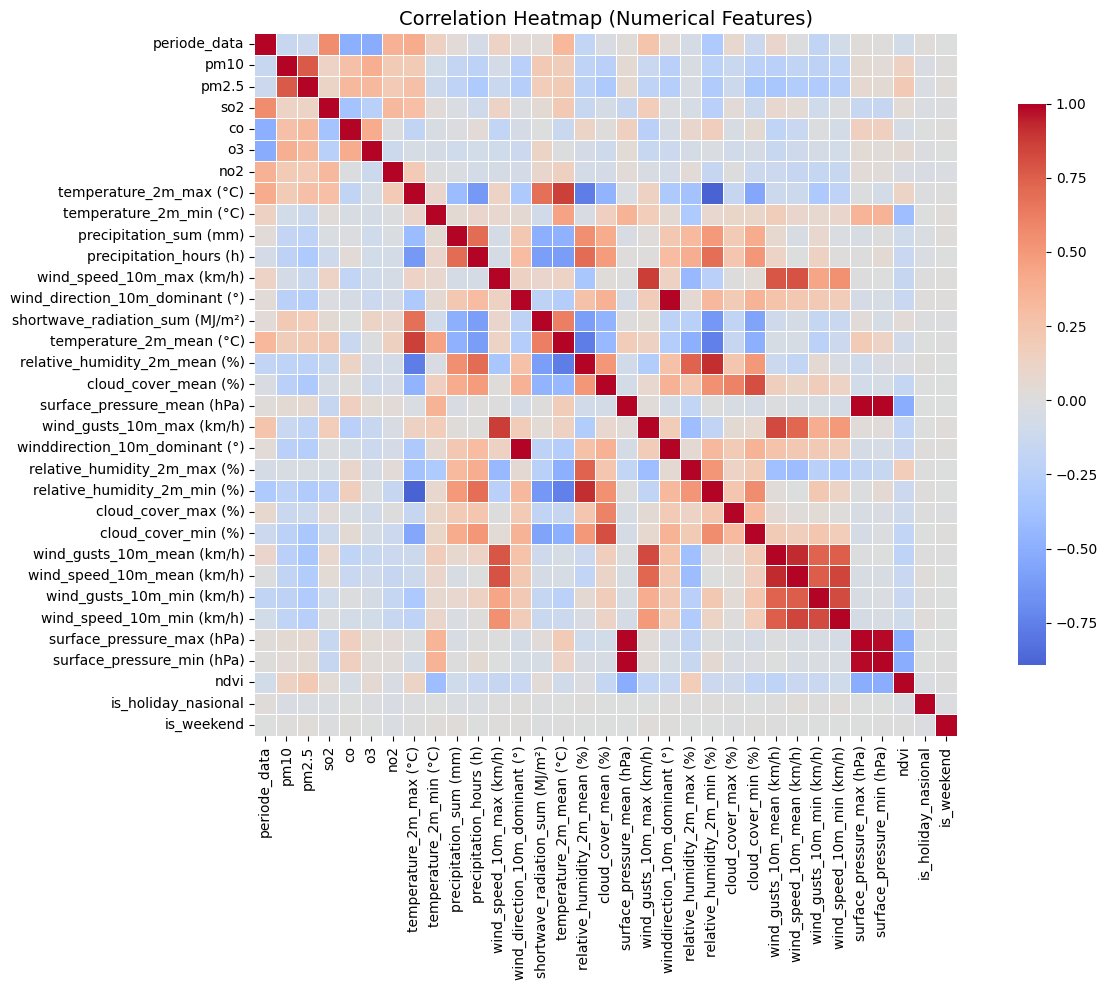

In [46]:
plt.figure(figsize=(14, 10))
corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap (Numerical Features)", fontsize=14)
plt.tight_layout()
plt.show()

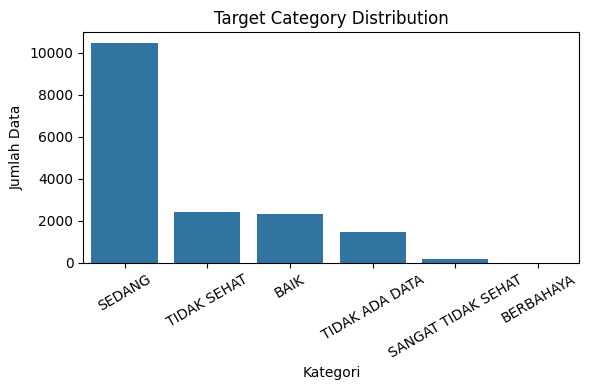

In [47]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x=target_col,
    order=df[target_col].value_counts().index
)

plt.title("Target Category Distribution")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [48]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["_target_enc"] = le.fit_transform(df[target_col])

print(dict(zip(le.classes_, le.transform(le.classes_))))

corr_target = (
    df[num_cols]
    .corrwith(df["_target_enc"])
    .sort_values(ascending=False)
)

corr_target

{'BAIK': np.int64(0), 'BERBAHAYA': np.int64(1), 'SANGAT TIDAK SEHAT': np.int64(2), 'SEDANG': np.int64(3), 'TIDAK ADA DATA': np.int64(4), 'TIDAK SEHAT': np.int64(5), nan: np.int64(6)}


pm2.5                              0.741860
pm10                               0.575838
o3                                 0.368065
no2                                0.256689
ndvi                               0.217739
so2                                0.200661
temperature_2m_max (°C)            0.173887
shortwave_radiation_sum (MJ/m²)    0.148978
co                                 0.145924
temperature_2m_mean (°C)           0.128639
relative_humidity_2m_max (%)       0.030915
is_weekend                         0.001160
is_holiday_nasional               -0.031965
surface_pressure_max (hPa)        -0.046938
surface_pressure_mean (hPa)       -0.048317
surface_pressure_min (hPa)        -0.056576
periode_data                      -0.061279
cloud_cover_max (%)               -0.072297
temperature_2m_min (°C)           -0.081213
relative_humidity_2m_mean (%)     -0.102488
precipitation_sum (mm)            -0.115158
precipitation_hours (h)           -0.141661
wind_speed_10m_max (km/h)       

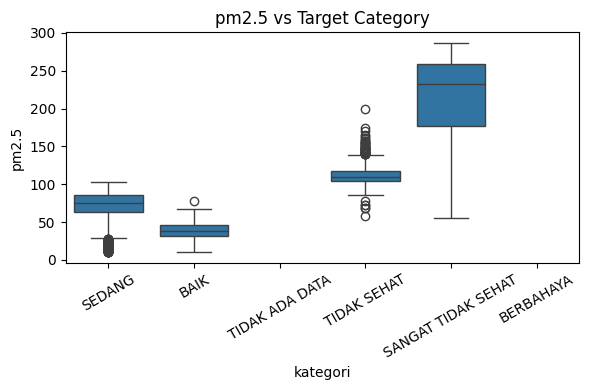

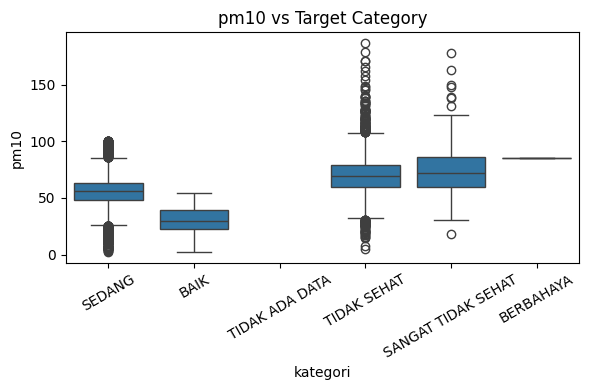

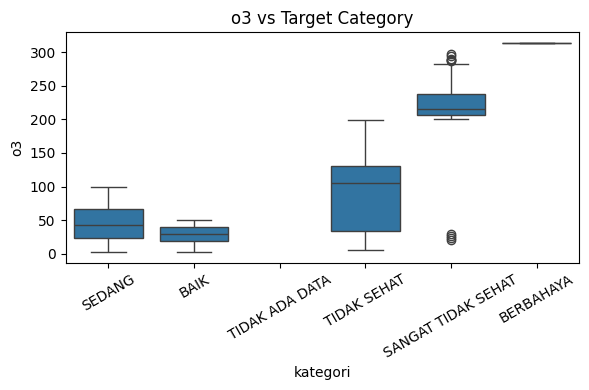

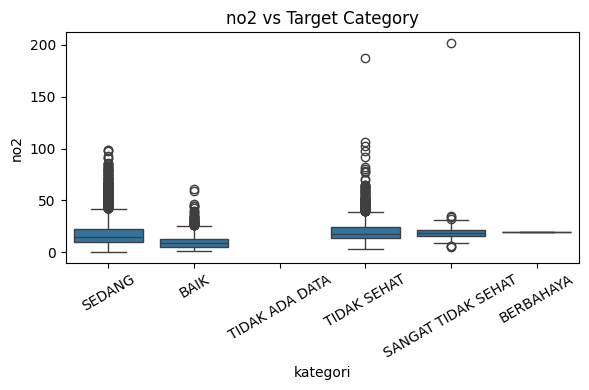

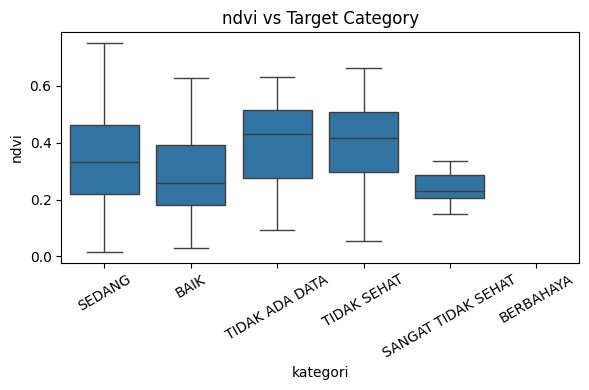

In [49]:
top_features = corr_target.abs().head(5).index

for col in top_features:
    plt.figure(figsize=(6, 4))
    
    sns.boxplot(
        data=df,
        x=target_col,
        y=col
    )
    
    plt.title(f"{col} vs Target Category")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


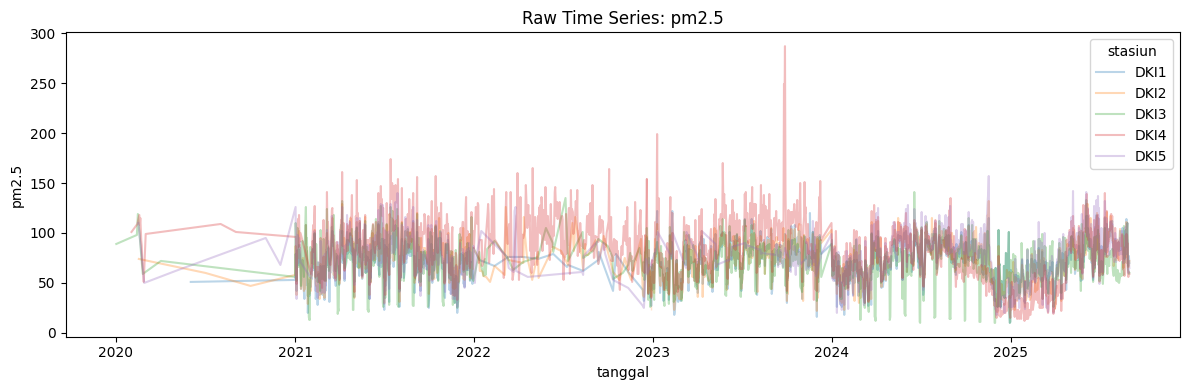

In [50]:
feature_to_plot = top_features[0]  

plt.figure(figsize=(12, 4))

sns.lineplot(
    data=df,
    x=date_col,
    y=feature_to_plot,
    hue=entity_col,
    alpha=0.3
)

plt.title(f"Raw Time Series: {feature_to_plot}")
plt.tight_layout()
plt.show()

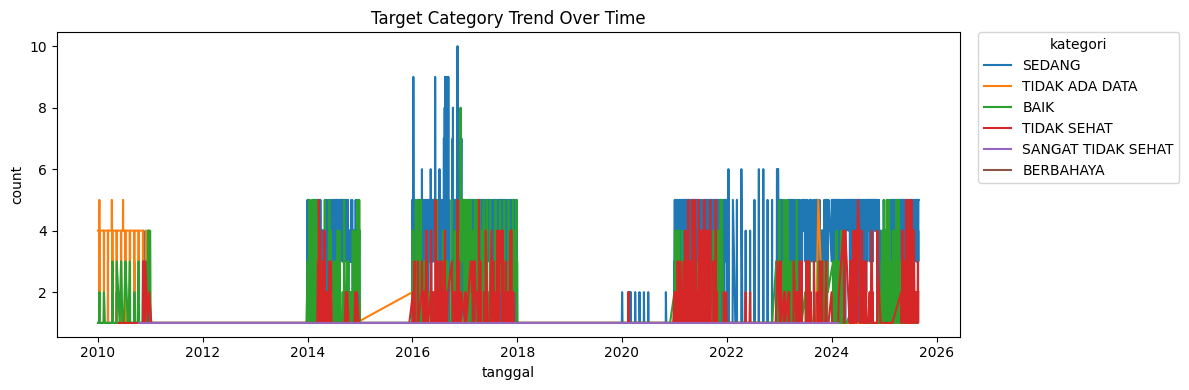

In [51]:
plt.figure(figsize=(12, 4))

target_time = (
    df
    .groupby([date_col, target_col])
    .size()
    .reset_index(name="count")
)

ax = sns.lineplot(
    data=target_time,
    x=date_col,
    y="count",
    hue=target_col
)

plt.title("Target Category Trend Over Time")

# pindahkan legend ke kanan luar
ax.legend(
    title=target_col,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

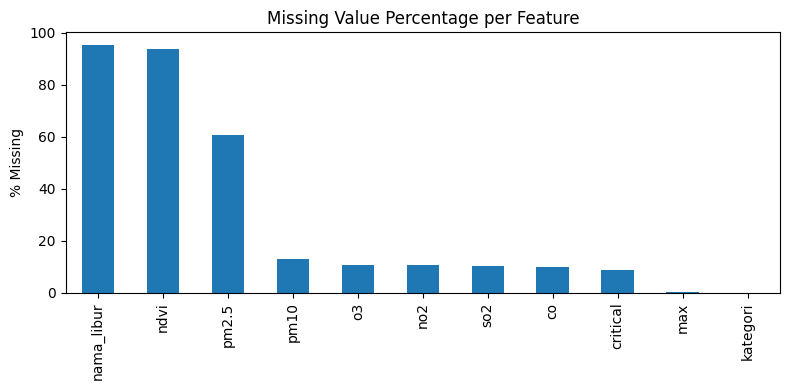

In [52]:
missing_pct = df.isna().mean().mul(100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
missing_pct.plot(kind="bar")

plt.title("Missing Value Percentage per Feature")
plt.ylabel("% Missing")
plt.tight_layout()
plt.show()

In [53]:
df = df.drop(columns="_target_enc", errors="ignore")

# DATA PREPARATION AND CLEANING

In [54]:
print("Shape:", df.shape)
print("\nKolom:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nHead:")
df.head()

print("\nDescribe (numerik):")
df.describe()

Shape: (16869, 40)

Kolom:
Index(['periode_data', 'tanggal', 'stasiun', 'pm10', 'pm2.5', 'so2', 'co',
       'o3', 'no2', 'max', 'critical', 'temperature_2m_max (°C)',
       'temperature_2m_min (°C)', 'precipitation_sum (mm)',
       'precipitation_hours (h)', 'wind_speed_10m_max (km/h)',
       'wind_direction_10m_dominant (°)', 'shortwave_radiation_sum (MJ/m²)',
       'temperature_2m_mean (°C)', 'relative_humidity_2m_mean (%)',
       'cloud_cover_mean (%)', 'surface_pressure_mean (hPa)',
       'wind_gusts_10m_max (km/h)', 'winddirection_10m_dominant (°)',
       'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)',
       'cloud_cover_max (%)', 'cloud_cover_min (%)',
       'wind_gusts_10m_mean (km/h)', 'wind_speed_10m_mean (km/h)',
       'wind_gusts_10m_min (km/h)', 'wind_speed_10m_min (km/h)',
       'surface_pressure_max (hPa)', 'surface_pressure_min (hPa)', 'ndvi',
       'is_holiday_nasional', 'nama_libur', 'is_weekend', 'day_name',
       'kategori'],
      dtype

,periode_data,tanggal,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,is_weekend
count,16869.000000,16869,14702.000000,6611.000000,15110.000000,15203.000000,15066.000000,15099.000000,16869.000000,16869.000000,...,16869.000000,16869.000000,16869.000000,16869.000000,16869.000000,16869.000000,16869.000000,1063.000000,16869.000000,16869.000000
mean,201813.850258,2018-07-26 01:30:29.130357248,54.098218,75.852216,27.907346,20.297178,53.443847,17.276310,30.655380,23.571142,...,44.768747,16.065197,6.441864,6.836689,2.295020,1008.621934,1004.551509,0.345579,0.045587,0.285672
min,201001.000000,2010-01-01 00:00:00,2.000000,10.000000,0.000000,0.000000,2.000000,0.000000,24.100000,18.600000,...,0.000000,8.400000,2.200000,0.700000,0.000000,998.900000,995.400000,0.013800,0.000000,0.000000
25%,201409.000000,2014-09-17 00:00:00,42.000000,60.000000,15.000000,11.000000,25.000000,10.000000,29.500000,23.000000,...,12.000000,13.000000,4.800000,4.700000,1.000000,1006.700000,1002.600000,0.228150,0.000000,0.000000
50%,201710.000000,2017-10-26 00:00:00,55.000000,77.000000,26.000000,18.000000,42.000000,15.000000,30.500000,23.600000,...,38.000000,14.800000,5.800000,6.100000,1.800000,1009.400000,1005.300000,0.340500,0.000000,0.000000
75%,202304.000000,2023-04-14 00:00:00,65.000000,91.000000,38.000000,26.000000,71.000000,22.000000,31.800000,24.100000,...,80.000000,17.700000,7.400000,7.900000,2.900000,1011.000000,1006.900000,0.469200,0.000000,1.000000
max,202508.000000,2025-08-31 00:00:00,187.000000,287.000000,112.000000,134.000000,314.000000,202.000000,38.800000,26.400000,...,100.000000,45.100000,22.500000,36.000000,18.900000,1015.400000,1011.700000,0.752100,1.000000,1.000000
std,482.397224,NaN,18.952786,24.138489,15.588834,12.187505,40.567872,11.559528,1.844864,0.859245,...,34.997233,4.495879,2.399150,3.413126,1.994611,3.095853,3.070620,0.146919,0.208593,0.451747


In [55]:
df = df.drop_duplicates(subset=["tanggal", "stasiun"])
dup_rows = df.duplicated(subset=[entity_col, date_col]).sum()
print("Jumlah duplikasi (entitas + tanggal):", dup_rows)

Jumlah duplikasi (entitas + tanggal): 0


In [56]:
cols_to_drop = ["periode_data", "max", "critical", "ndvi", "nama_libur", "day_name"]
df = df.drop(columns=cols_to_drop, errors="ignore")
df.tail()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),is_holiday_nasional,is_weekend,kategori
16864,2025-08-27,DKI5,57.0,110.0,25.0,11.0,84.0,46.0,37.3,24.0,...,0,16.4,4.6,7.6,1.9,1011.2,1005.6,0,0,TIDAK SEHAT
16865,2025-08-28,DKI5,32.0,68.0,25.0,7.0,31.0,28.0,35.1,24.2,...,4,20.9,6.1,9.7,2.0,1011.0,1006.7,0,0,SEDANG
16866,2025-08-29,DKI5,27.0,60.0,24.0,6.0,37.0,27.0,33.2,23.8,...,18,14.7,4.2,6.8,0.4,1011.9,1006.9,0,0,SEDANG
16867,2025-08-30,DKI5,38.0,72.0,26.0,9.0,30.0,40.0,32.7,24.6,...,35,17.4,5.5,7.9,1.6,1011.0,1006.7,0,1,SEDANG
16868,2025-08-31,DKI5,37.0,65.0,25.0,9.0,21.0,34.0,31.6,23.8,...,8,14.5,3.6,2.5,0.2,1010.7,1006.9,0,1,SEDANG


In [57]:
df = df[df["tanggal"].dt.year != 2010]
df["tanggal"].dt.year.value_counts().sort_index()
df = df.sort_values(["tanggal", "stasiun"]).reset_index(drop=True)


In [58]:
df.head()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),is_holiday_nasional,is_weekend,kategori
0,2011-01-01,DKI3,52.0,NaN,17.0,51.0,76.0,7.0,29.6,23.8,...,97,24.0,11.3,11.9,5.7,999.6,995.6,1,1,SEDANG
1,2011-01-02,DKI4,56.0,NaN,20.0,22.0,29.0,11.0,30.0,24.1,...,97,22.0,10.4,11.5,4.5,1004.9,1000.9,0,1,SEDANG
2,2011-01-03,DKI2,40.0,NaN,14.0,26.0,42.0,8.0,28.0,24.5,...,83,26.1,11.2,12.6,5.4,1008.4,1005.3,0,0,BAIK
3,2011-01-04,DKI4,45.0,NaN,14.0,20.0,21.0,8.0,28.4,23.4,...,96,25.1,10.8,9.7,5.4,1004.6,1001.0,0,0,BAIK
4,2011-01-05,DKI1,71.0,NaN,18.0,54.0,88.0,31.0,28.0,23.7,...,85,16.2,5.2,6.5,1.1,1007.7,1004.3,0,0,SEDANG


In [59]:
df["kategori"] = df["kategori"].replace("TIDAK ADA DATA", np.nan)

df["kategori"].value_counts(dropna=False)

kategori
SEDANG                10003
TIDAK SEHAT            2363
BAIK                   2109
SANGAT TIDAK SEHAT      196
NaN                     157
BERBAHAYA                 1
Name: count, dtype: int64

In [60]:
df.head(10)

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),is_holiday_nasional,is_weekend,kategori
0,2011-01-01,DKI3,52.0,NaN,17.0,51.0,76.0,7.0,29.6,23.8,...,97,24.0,11.3,11.9,5.7,999.6,995.6,1,1,SEDANG
1,2011-01-02,DKI4,56.0,NaN,20.0,22.0,29.0,11.0,30.0,24.1,...,97,22.0,10.4,11.5,4.5,1004.9,1000.9,0,1,SEDANG
2,2011-01-03,DKI2,40.0,NaN,14.0,26.0,42.0,8.0,28.0,24.5,...,83,26.1,11.2,12.6,5.4,1008.4,1005.3,0,0,BAIK
3,2011-01-04,DKI4,45.0,NaN,14.0,20.0,21.0,8.0,28.4,23.4,...,96,25.1,10.8,9.7,5.4,1004.6,1001.0,0,0,BAIK
4,2011-01-05,DKI1,71.0,NaN,18.0,54.0,88.0,31.0,28.0,23.7,...,85,16.2,5.2,6.5,1.1,1007.7,1004.3,0,0,SEDANG
5,2011-01-06,DKI4,91.0,NaN,21.0,70.0,82.0,23.0,29.2,22.7,...,76,18.5,6.7,8.6,2.6,1005.7,1001.3,0,0,SEDANG
6,2011-01-07,DKI4,85.0,NaN,14.0,33.0,65.0,19.0,28.9,23.4,...,99,18.0,7.9,7.6,3.8,1005.0,1001.6,0,0,SEDANG
7,2011-01-08,DKI4,110.0,NaN,20.0,23.0,67.0,16.0,28.3,22.8,...,69,18.4,7.4,9.0,2.2,1004.5,1000.7,0,1,TIDAK SEHAT
8,2011-01-09,DKI2,68.0,NaN,10.0,13.0,97.0,14.0,28.0,23.3,...,83,27.6,10.8,15.8,4.1,1007.9,1003.7,0,1,SEDANG
9,2011-01-10,DKI4,81.0,NaN,17.0,24.0,124.0,20.0,29.1,23.5,...,86,32.7,15.7,14.4,10.9,1003.9,999.1,0,0,TIDAK SEHAT


Interpolasi

In [61]:
cols_interp = ["pm10", "so2", "co", "o3", "no2"]

df = df.sort_values(["stasiun", "tanggal"])

# interpolasi per stasiun dengan datetime index
def interpolate_station(x):
    x = x.set_index("tanggal")  # index harus datetime
    x = x.interpolate(method="time", limit_direction="both")
    return x.reset_index()  # kembalikan index jadi kolom

df[cols_interp] = (
    df.groupby("stasiun")[["tanggal"] + cols_interp]
      .apply(interpolate_station)
      .drop(columns="tanggal")  # karena sudah di df asli
      .reset_index(drop=True)
)

In [62]:
df["pm2.5"] = df["pm2.5"].fillna(df["pm10"] * 1.5)

In [63]:
df = df.dropna(subset=["kategori"])

In [64]:
df = df.sort_values(["tanggal", "stasiun"]).reset_index(drop=True)
df.head()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),is_holiday_nasional,is_weekend,kategori
0,2011-01-01,DKI3,71.0,106.5,18.0,54.0,88.0,31.0,29.6,23.8,...,97,24.0,11.3,11.9,5.7,999.6,995.6,1,1,SEDANG
1,2011-01-02,DKI4,49.0,73.5,16.0,26.0,44.0,16.0,30.0,24.1,...,97,22.0,10.4,11.5,4.5,1004.9,1000.9,0,1,SEDANG
2,2011-01-03,DKI2,35.0,52.5,15.0,15.0,47.0,11.0,28.0,24.5,...,83,26.1,11.2,12.6,5.4,1008.4,1005.3,0,0,BAIK
3,2011-01-04,DKI4,41.0,61.5,16.0,35.0,31.0,15.0,28.4,23.4,...,96,25.1,10.8,9.7,5.4,1004.6,1001.0,0,0,BAIK
4,2011-01-05,DKI1,69.0,103.5,22.0,31.0,69.0,28.0,28.0,23.7,...,85,16.2,5.2,6.5,1.1,1007.7,1004.3,0,0,SEDANG


In [65]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14672 entries, 0 to 14671
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   tanggal                          14672 non-null  datetime64[ns]
 1   stasiun                          14672 non-null  object        
 2   pm10                             14672 non-null  float64       
 3   pm2.5                            14672 non-null  float64       
 4   so2                              14672 non-null  float64       
 5   co                               14672 non-null  float64       
 6   o3                               14672 non-null  float64       
 7   no2                              14672 non-null  float64       
 8   temperature_2m_max (°C)          14672 non-null  float64       
 9   temperature_2m_min (°C)          14672 non-null  float64       
 10  precipitation_sum (mm)           14672 non-null  float64  

tanggal                            0
stasiun                            0
pm10                               0
pm2.5                              0
so2                                0
co                                 0
o3                                 0
no2                                0
temperature_2m_max (°C)            0
temperature_2m_min (°C)            0
precipitation_sum (mm)             0
precipitation_hours (h)            0
wind_speed_10m_max (km/h)          0
wind_direction_10m_dominant (°)    0
shortwave_radiation_sum (MJ/m²)    0
temperature_2m_mean (°C)           0
relative_humidity_2m_mean (%)      0
cloud_cover_mean (%)               0
surface_pressure_mean (hPa)        0
wind_gusts_10m_max (km/h)          0
winddirection_10m_dominant (°)     0
relative_humidity_2m_max (%)       0
relative_humidity_2m_min (%)       0
cloud_cover_max (%)                0
cloud_cover_min (%)                0
wind_gusts_10m_mean (km/h)         0
wind_speed_10m_mean (km/h)         0
w

In [66]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

numeric_cols = df.select_dtypes(include=["float64","int64"]).columns.tolist()

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

le = LabelEncoder()
df["kategori_enc"] = le.fit_transform(df["kategori"])

df = df.sort_values(["stasiun","tanggal"]).reset_index(drop=True)

In [69]:
df.head()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),is_holiday_nasional,is_weekend,kategori,kategori_enc
0,2011-01-05,DKI1,0.362162,0.353873,0.189189,0.231343,0.214744,0.138614,0.265306,0.653846,...,0.212534,0.147783,0.164306,0.058201,0.533333,0.55625,0.0,0.0,SEDANG,3
1,2011-01-20,DKI1,0.340541,0.332746,0.126126,0.313433,0.269231,0.108911,0.217687,0.576923,...,0.231608,0.211823,0.203966,0.042328,0.612121,0.63125,0.0,0.0,BAIK,0
2,2011-02-01,DKI1,0.313514,0.306338,0.135135,0.470149,0.224359,0.103960,0.258503,0.692308,...,0.250681,0.320197,0.254958,0.238095,0.642424,0.67500,0.0,0.0,BAIK,0
3,2011-03-01,DKI1,0.264865,0.258803,0.009009,0.246269,0.173077,0.089109,0.183673,0.602564,...,0.512262,0.576355,0.490085,0.518519,0.690909,0.68750,0.0,0.0,BAIK,0
4,2011-03-05,DKI1,0.227027,0.221831,0.009009,0.208955,0.160256,0.074257,0.258503,0.679487,...,0.359673,0.354680,0.305949,0.285714,0.654545,0.68750,1.0,1.0,SEDANG,3


# LSTM

In [67]:
# import numpy as np
# import pandas as pd
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from tensorflow.keras.callbacks import EarlyStopping
# from sklearn.metrics import f1_score, classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns

# SEED = 42
# np.random.seed(SEED)
# import tensorflow as tf
# tf.random.set_seed(SEED)

# # ==========================
# # 0. Pilih fitur numeric + flag
# # ==========================
# lstm_features = numeric_cols
# lstm_df = df[["stasiun", "tanggal"] + lstm_features + ["kategori_enc"]].copy()

# # ==========================
# # 1. Buat windowing / sequence
# # ==========================
# SEQ_LEN = 3 
# X_seq = []
# y_seq = []
# dates_seq = []
# stations_seq = []

# # urutkan dulu
# lstm_df = lstm_df.sort_values(["stasiun", "tanggal"]).reset_index(drop=True)

# for st in lstm_df["stasiun"].unique():
#     st_data = lstm_df[lstm_df["stasiun"] == st]
#     feature_data = st_data[lstm_features].values
#     target_data = st_data["kategori_enc"].values
#     date_data = st_data["tanggal"].values
#     for i in range(SEQ_LEN, len(st_data)):
#         X_seq.append(feature_data[i-SEQ_LEN:i])
#         y_seq.append(target_data[i])
#         dates_seq.append(date_data[i])
#         stations_seq.append(st)

# X_seq = np.array(X_seq)
# y_seq = np.array(y_seq)
# dates_seq = np.array(dates_seq)
# stations_seq = np.array(stations_seq)

# # ==========================
# # 2. Split train / val berdasarkan tanggal
# # ==========================
# train_mask = dates_seq < np.datetime64("2025-09-01")
# val_mask   = (dates_seq >= np.datetime64("2025-08-01")) & (dates_seq <= np.datetime64("2025-08-31"))

# X_train_lstm = X_seq[train_mask]
# y_train_lstm = y_seq[train_mask]

# X_val_lstm   = X_seq[val_mask]
# y_val_lstm   = y_seq[val_mask]

# num_classes = len(le.classes_)

# # ==========================
# # 3. Bangun model LSTM
# # ==========================
# lstm_model = Sequential([
#     LSTM(64, input_shape=(SEQ_LEN, X_train_lstm.shape[2]), return_sequences=False),
#     Dropout(0.2),
#     Dense(32, activation="relu"),
#     Dense(num_classes, activation="softmax")
# ])

# lstm_model.compile(loss="sparse_categorical_crossentropy",
#                    optimizer="adam",
#                    metrics=["accuracy"])

# # ==========================
# # 4. Training dengan early stopping
# # ==========================
# early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
# history_lstm = lstm_model.fit(
#     X_train_lstm, y_train_lstm,
#     validation_data=(X_val_lstm, y_val_lstm),
#     epochs=200,
#     batch_size=32,
#     callbacks=[early_stop],
#     verbose=10
# )

# # ==========================
# # 5. Evaluasi
# # ==========================
# y_pred_val_lstm = np.argmax(lstm_model.predict(X_val_lstm), axis=1)
# macro_f1_lstm = f1_score(y_val_lstm, y_pred_val_lstm, average="macro")
# print("Validation Macro F1 Score (LSTM):", macro_f1_lstm)

# print("\nClassification Report (LSTM):\n", classification_report(
#     y_val_lstm, y_pred_val_lstm,
#     labels=np.arange(num_classes),
#     target_names=le.classes_
# ))

# cm_lstm = confusion_matrix(y_val_lstm, y_pred_val_lstm, labels=np.arange(num_classes))
# plt.figure(figsize=(8,6))
# sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Blues",
#             xticklabels=le.classes_, yticklabels=le.classes_)
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix - Validation Set (LSTM)")
# plt.show()


In [68]:
# # ==========================
# # Prediksi "future" test set (auto-regressive) LSTM
# # ==========================
# from datetime import timedelta

# # Tentukan tanggal test
# test_dates = pd.date_range("2025-09-01", "2025-11-30", freq="D")

# submission_rows = []

# # Loop tanggal dulu, baru stasiun DKI1-5
# stasiun_list = sorted(lstm_df["stasiun"].unique(), key=lambda x: int(x.upper().replace("DKI","")))

# for d in test_dates:
#     for st in stasiun_list:
#         # Ambil data terakhir SEQ_LEN hari sebagai seed
#         st_data = lstm_df[lstm_df["stasiun"] == st].sort_values("tanggal")
#         last_seq = st_data[lstm_features].values[-SEQ_LEN:].copy()  # shape (SEQ_LEN, num_features)

#         # Buat input LSTM dengan bentuk (1, SEQ_LEN, num_features)
#         X_input = last_seq[np.newaxis, :, :]

#         # Prediksi kategori
#         y_pred = np.argmax(lstm_model.predict(X_input), axis=1)[0]

#         # Simpan untuk submission
#         submission_rows.append({
#             "id": f"{d.strftime('%Y-%m-%d')}_{st}",
#             "kategori": le.inverse_transform([y_pred])[0]
#         })

#         # Geser window untuk hari berikutnya (auto-regressive)
#         next_row = last_seq[-1].copy()  # copy hari terakhir
#         for idx, col in enumerate(lstm_features):
#             if col in ["pm2.5", "ndvi"]:
#                 next_row[idx] = -1  # default value untuk future
#         last_seq = np.vstack([last_seq[1:], next_row])  # geser window

# # Buat DataFrame submission
# submission_lstm = pd.DataFrame(submission_rows)

# # Sort ulang berdasarkan tanggal & nomor stasiun
# # Extract nomor stasiun (case-insensitive) dan konversi ke int
# submission_lstm["stasiun_num"] = submission_lstm["id"].str.extract(r"(?i)dki(\d+)")[0].astype(int)

# # Sort dan reset index
# submission_lstm = submission_lstm.sort_values(["id", "stasiun_num"]).reset_index(drop=True)
# submission_lstm = submission_lstm.drop(columns="stasiun_num")

# # Simpan CSV
# submission_lstm.to_csv("submission_lstm2.csv", index=False)
# print("File submission_lstm2.csv siap!")
